In [5]:
from scipy.stats import beta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa

import sys

sys.path.append("../src")  # or "../src" if the notebook is inside /notebooks
sys.path.append("..")  # or "../src" if the notebook is inside /notebooks


INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


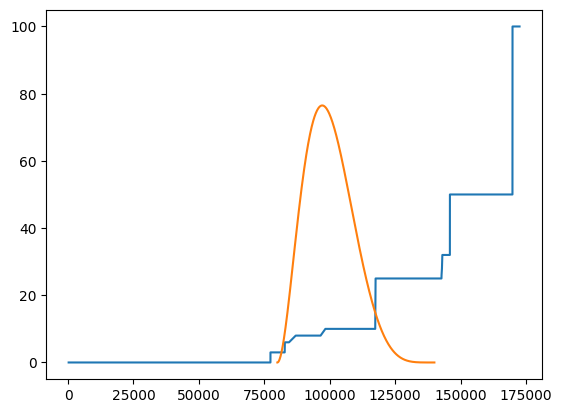

In [6]:
net = pypsa.examples.scigrid_de()


mc = net.get_switchable_as_dense('Generator', 'marginal_cost').iloc[0]
mc_sorted_index = mc.sort_values().index
p_sort_cs = net.generators.p_nom.loc[mc_sorted_index].cumsum()

plt.plot(p_sort_cs, mc.loc[mc_sorted_index])

# Desired mean and concentration
np_min = 80000
np_max = 140000
mean = 100000
mu = (mean - np_min) / (np_max - np_min)  # Normalize mean to [0, 1]
# mu = 0.5 
kappa = 9


# Compute alpha and beta
alpha = mu * kappa
beta_param = (1 - mu) * kappa


input_array = np.linspace(np_min, np_max, 100)
# 
# Define Beta distribution
dist = beta(alpha, beta_param)

# Plot PDF
x = np.linspace(np_min, np_max, 500)

pdf =  30 * dist.pdf((x - np_min) / (np_max - np_min))  # Adjust x to start from np_min
plt.plot(x, pdf, label=f'Beta(α={alpha:.2f}, β={beta_param:.2f})')

In [3]:
net.add('Generator', net.buses.index, bus=net.buses.index, p_nom=5000, marginal_cost=1000)
net.optimize.optimize_security_constrained(solver_name='gurobi', snapshots=net.snapshots[0])

Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='Transformer')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 17.64s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2026-01-14


INFO:gurobipy:Academic license - for non-commercial use only - expires 2026-01-14


...

Solved in 3924 iterations and 43.95 seconds (21.82 work units)


INFO:gurobipy:Solved in 3924 iterations and 43.95 seconds (21.82 work units)


Optimal objective  3.656199298e+06


INFO:gurobipy:Optimal objective  3.656199298e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3070 primals, 1804535 duals
Objective: 3.66e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Transformer-fix-s-lower-security-for-Transformer-outage-in-<pypsa.networks.SubNetwork object at 0x00000206EAB49710>, Transformer-fix-s-upper-security-for-Transformer-outage-in-<pypsa.networks.SubNetwork object at 0x00000206EAB49710>, Line-fix-s-lower-security-for-Transformer-outage-in-<pypsa.netwo

('ok', 'optimal')

In [7]:
net.model.constraints['Line-fix-s-lower-security-for-Transformer-outage-in-<pypsa.networks.SubNetwork object at 0x00000206EAB49710>']

Constraint `Line-fix-s-lower-security-for-Transformer-outage-in-<pypsa.networks.SubNetwork object at 0x00000206EAB49710>` [snapshot: 1, Line-fix: 852, Transformer-outage: 96]:
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2011-01-01 00:00:00, 1, 2]: +1 Line-s[2011-01-01 00:00:00, 1]                                                           ≥ -495.366530965
[2011-01-01 00:00:00, 1, 5]: +1 Line-s[2011-01-01 00:00:00, 1]                                                           ≥ -495.366530965
[2011-01-01 00:00:00, 1, 10]: +1 Line-s[2011-01-01 00:00:00, 1]                                                          ≥ -495.366530965
[2011-01-01 00:00:00, 1, 12]: +1 Line-s[2011-01-01 00:00:00, 1]                                                          ≥ -495.366530965
[2011-01-01 00:00:00, 1, 13]: +1 Line-s[2011-01-01 00:00:00, 1]                                 

In [7]:
from fbmc.core.constraints.security_constrained import optimize_security_constrained

net = optimize_security_constrained(net, snapshots=net.snapshots[0])

Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='Transformer')


In [8]:
net.model

Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Line-s (snapshot, Line)
 * Transformer-s (snapshot, Transformer)
 * StorageUnit-p_dispatch (snapshot, StorageUnit)
 * StorageUnit-p_store (snapshot, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, StorageUnit)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Line-fix-s-lower (snapshot, Line-fix)
 * Line-fix-s-upper (snapshot, Line-fix)
 * Transformer-fix-s-lower (snapshot, Transformer-fix)
 * Transformer-fix-s-upper (snapshot, Transformer-fix)
 * StorageUnit-fix-p_dispatch-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_dispatch-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-upper (snapshot, StorageUnit-